Group Members: Nicolas Banatt, Annanya Jain, James McDermott, Yanran Jia

In [1]:
!python --version

Python 3.12.1


In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('MergedData_clean.csv')

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,baseline,910.0,629.0,256.0,...,32.0,32.5,ellip,read,0.50,0.00,90.0,3.33,30.0,24.0
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.33,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.33,30.0,39.0
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,baseline,680.0,546.0,127.0,...,33.0,32.1,cycle,wrdgms,0.00,0.00,83.0,48.33,26.0,20.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.17,23.0,19.0


In [5]:
# Change RRVch (our target) to binary label for classification
df["RRV_label"] = (df["RRVch"] > 0).astype(int)

# 1. Extract the baseline rows (one per participant)
baseline = df[df["Assmnt"] == "baseline"][["ID", "RRVscore"]]
baseline = baseline.rename(columns={"RRVscore": "Baseline_RRVscore"})

# 2. Keep only pstwash and endposttr rows
post = df[df["Assmnt"].isin(["pstwash", "endposttr"])]

# 3. Merge baseline RRVscore onto these rows
merged = post.merge(baseline, on="ID", how="left")

# merged now contains:
#   • all pstwash and endposttr rows
#   • baseline RRVscore appended for each participant

df = merged
df.drop(columns=[])


df.dropna(subset=["Baseline_RRVscore"])

df["Assmnt"] = df["Assmnt"].map({
    "endposttr": 6,
    "pstwash": 10
})

df = df[df["ID"] != 25]

df = df.drop(columns = ['RRVscore','RRV_Pgoal','RRV_Agoal','Gender','Group','Height','Age','BMI','Participant','ID','Race','Ethnicity','Avg_Daily_Week_Min','RRVch','oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
df.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


## K-Nearest Neighbors

In [6]:
from sklearn.preprocessing import MinMaxScaler
# James

knn_df = df.copy()

knn_df.dropna(subset=["Baseline_RRVscore"])

attr = knn_df.drop(columns = ['RRV_label'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
target = knn_df['RRV_label']  # target variable
attr.head()


,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,0.50
1,10,579.0,229.0,40.0,0.0,0.0,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0.75


In [7]:
scaler = MinMaxScaler()
attr = pd.DataFrame(scaler.fit_transform(attr), columns=attr.columns)
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,0.0,0.277690,0.585714,0.783333,0.571429,0.0,0.50
1,1.0,0.323576,0.530952,0.666667,0.000000,0.0,0.50
2,0.0,0.268987,0.228571,0.183333,0.000000,0.0,0.00
3,1.0,0.276108,0.264286,0.083333,0.000000,0.0,0.00
4,1.0,0.208861,0.700000,0.300000,0.000000,0.0,0.75


In [8]:
from sklearn.model_selection._split import train_test_split

attr_train, attr_test, target_train,target_test  = train_test_split(attr, target, test_size = 0.3, shuffle = True)
target_train.head()
attr_train.head()


,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
110,0.0,0.753956,0.564286,0.316667,0.000000,0.0,0.000000
93,0.0,0.825949,0.311905,0.316667,0.000000,0.0,1.000000
50,0.0,0.248418,0.828571,0.100000,0.000000,0.0,0.857143
118,1.0,0.655063,0.552381,0.583333,0.285714,0.0,1.000000
108,1.0,0.798259,0.309524,0.333333,0.000000,0.0,0.250000


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 10, 5]
 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(attr_train, target_train)
    target_pred = knn.predict(attr_test)
    accuracy = accuracy_score(target_test,target_pred ) 
    print(f'Accuracy of model with k = {k}: {accuracy}')
    print('')

Accuracy of model with k = 3: 0.6486486486486487

Accuracy of model with k = 10: 0.5405405405405406

Accuracy of model with k = 5: 0.6756756756756757



In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(target_test, target_pred)

print('Confusion Matrix')
print(confusion_matrix(target_test, target_pred))
print()
print('Accuracy score')
print(accuracy_score(target_test, target_pred))
print()
print('Classification Report')
print(classification_report(target_test, target_pred))

Confusion Matrix
[[16  4]
 [ 8  9]]

Accuracy score
0.6756756756756757

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        20
           1       0.69      0.53      0.60        17

    accuracy                           0.68        37
   macro avg       0.68      0.66      0.66        37
weighted avg       0.68      0.68      0.67        37



In [11]:
test_actual=attr_test
test_actual['target_pred']=target_pred
test_actual['test_actual']=target_test
test_actual.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore,target_pred,test_actual
31,1.0,0.280854,0.376190,0.300000,0.142857,0.285714,1.000000,0,0.0
89,0.0,0.783228,0.435714,0.416667,0.142857,0.000000,0.000000,1,1.0
29,1.0,0.214399,0.561905,0.100000,0.000000,0.000000,0.400000,0,1.0
95,0.0,0.847310,0.288095,0.133333,0.000000,0.000000,0.666667,0,NaN
19,0.0,0.319620,0.423810,0.600000,0.000000,0.000000,0.500000,1,1.0


In [12]:
freq_table =pd.crosstab( test_actual['test_actual'], test_actual['target_pred'])
print("Confusion Matrix")
print(freq_table)

Confusion Matrix
target_pred  0  1
test_actual      
0.0          6  2
1.0          6  5


[Text(0, 0.5, '0(No_Increase)'), Text(0, 1.5, '1(Increase_Motiv)')]

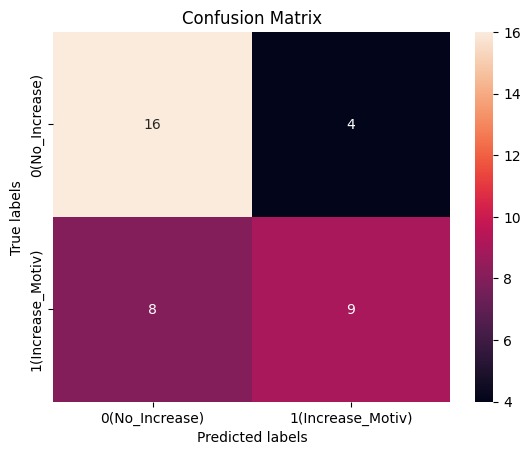

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt     

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])
ax.yaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])

## CART (Nicolas)

In [14]:
cart_attr = df.drop(columns = ["Participant", "ID"])

KeyError: "['Participant', 'ID'] not found in axis"

## Naive Bayes

In [ ]:
# James
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

nb_df = df.copy()

target = nb_df['RRV_label']

# Split the data into training and testing sets
attr_train, attr_test, target_train, target_test = train_test_split(attr, target, test_size=0.3, random_state=5)

categorical_columns=['Assmnt','Avg_Daily_Sed_Week_Min','Avg_Daily_Light_Week_Min','Avg_Daily_Mod_Week_Min','Avg_Daily_Vig_Week_Min','Avg_Daily_Very_Vig_Week_Min','Baseline_RRVscore']
# Create preprocessor for categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical_columns) ])
# Create a Categorical Naive Bayes model
cnb = CategoricalNB()

# Create a pipeline with preprocessing and model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', cnb)])
# Train the model
model.fit(attr_train, target_train)

# # Make predictions on the test set
target_pred = model.predict(attr_test)

attr_test.head()

ValueError: Found unknown categories [np.float64(0.0925632911392405), np.float64(0.10996835443037975), np.float64(0.12341772151898733), np.float64(0.12579113924050633), np.float64(0.13212025316455694), np.float64(0.13449367088607594), np.float64(0.15427215189873417), np.float64(0.1685126582278481), np.float64(0.19936708860759494), np.float64(0.22547468354430378), np.float64(0.22784810126582278), np.float64(0.22943037974683544), np.float64(0.23259493670886078), np.float64(0.2333860759493671), np.float64(0.23734177215189872), np.float64(0.23971518987341772), np.float64(0.254746835443038), np.float64(0.25949367088607594), np.float64(0.26186708860759494), np.float64(0.2848101265822785), np.float64(0.2974683544303797), np.float64(0.3322784810126582), np.float64(0.36787974683544306), np.float64(0.4968354430379747), np.float64(0.6661392405063291), np.float64(0.6740506329113924), np.float64(0.6867088607594936), np.float64(0.7072784810126582), np.float64(0.7175632911392404), np.float64(0.776107

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# Evaluate the accuracy
accuracy = accuracy_score(target_test, target_pred)
print(f'Accuracy: {accuracy}')
print()
print(confusion_matrix(target_test, target_pred))
print()
print('Classification Report')
print(classification_report(target_test, target_pred))

## Random Forest

In [ ]:
# James


## Artificial Neural Network (Nicolas)

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

In [ ]:
# Split target variable and attributes
attr = df.drop(columns=['id', 'diagnosis'])
target = df['diagnosis']

KeyError: "['id', 'diagnosis'] not found in axis"

## Hierarchical Clustering

## K-Means Clustering

## Support Vector Machine

## MiniSOM